In [160]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [161]:
df = pd.DataFrame()

In [162]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [163]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

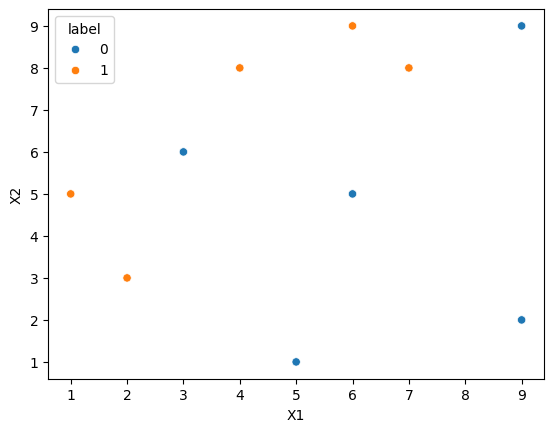

In [164]:
import seaborn as sns
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])

In [165]:
df['weights'] = 1/df.shape[0]

In [166]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [167]:
from sklearn.tree import DecisionTreeClassifier

In [168]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [169]:
X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [170]:
dt1.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

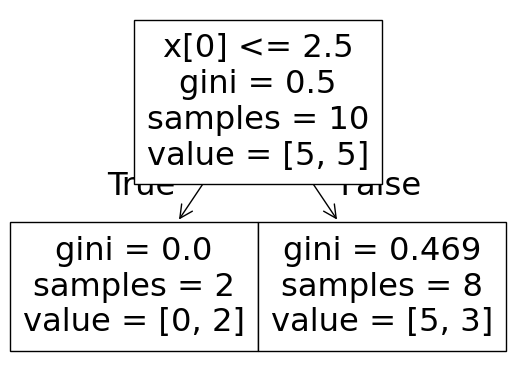

In [171]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

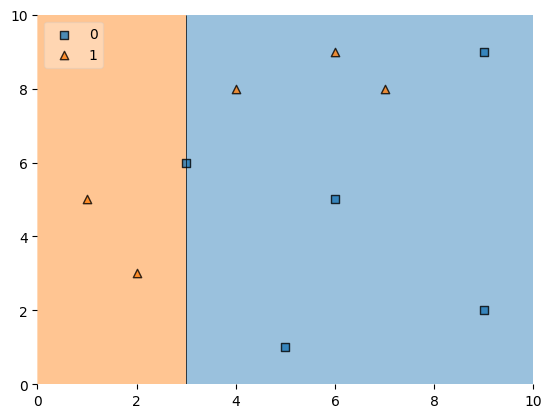

In [172]:
plot_decision_regions(X, y, clf=dt1, legend=2)

In [173]:
df['y_pred'] = dt1.predict(X)

In [174]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [175]:
def calculate_model_weight(error):

  return 0.5*np.log((1-error)/(error))

In [176]:
# Step 3 - calculate model weight
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [177]:
# Step 4 - Update weights
def update_row_weights(row,alpha=0.423):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [178]:
df['updated_weights'] = df.apply(update_row_weights,axis=1)

In [179]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,0,0.065508
3,4,8,1,0.1,0,0.152653
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,0,0.152653
6,6,5,0,0.1,0,0.065508
7,7,8,1,0.1,0,0.152653
8,9,9,0,0.1,0,0.065508
9,9,2,0,0.1,0,0.065508


In [180]:
df['updated_weights'].sum()

np.float64(0.9165153319682015)

In [181]:
df['nomalized_weights'] = df['updated_weights']/df['updated_weights'].sum()

In [182]:
df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,0,0.065508,0.071475
3,4,8,1,0.1,0,0.152653,0.166559
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,0,0.152653,0.166559
6,6,5,0,0.1,0,0.065508,0.071475
7,7,8,1,0.1,0,0.152653,0.166559
8,9,9,0,0.1,0,0.065508,0.071475
9,9,2,0,0.1,0,0.065508,0.071475


In [183]:
df['nomalized_weights'].sum()

np.float64(1.0)

In [184]:
df['cumsum_upper'] = np.cumsum(df['nomalized_weights'])

In [185]:
df['cumsum_lower'] = df['cumsum_upper'] - df['nomalized_weights']

In [186]:
df[['X1','X2','label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,0,0.065508,0.142950,0.214425
3,4,8,1,0.1,0,0.152653,0.214425,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,0,0.152653,0.452458,0.619017
6,6,5,0,0.1,0,0.065508,0.619017,0.690492
7,7,8,1,0.1,0,0.152653,0.690492,0.857050
8,9,9,0,0.1,0,0.065508,0.857050,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


In [187]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [188]:
index_values = create_new_dataset(df)

In [189]:
index_values

[4, 7, 8, 9, 8, 9, 9, 5, 2, 7]

In [190]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [191]:
second_df

,X1,X2,label,weights
4,5,1,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1
8,9,9,0,0.1
9,9,2,0,0.1
9,9,2,0,0.1
5,6,9,1,0.1
2,3,6,0,0.1
7,7,8,1,0.1


In [192]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [193]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [194]:
dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 7.0\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.48\nsamples = 5\nvalue = [2, 3]'),
 Text(0.625, 0.5, '  False')]

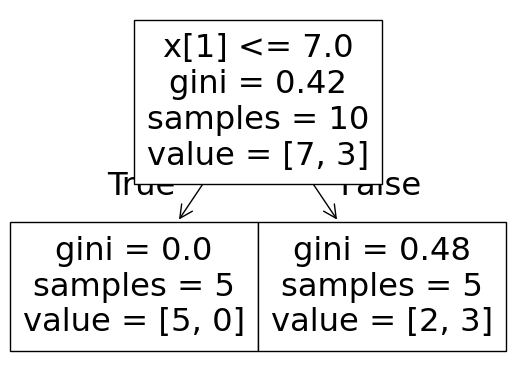

In [195]:
plot_tree(dt2)

<Axes: >

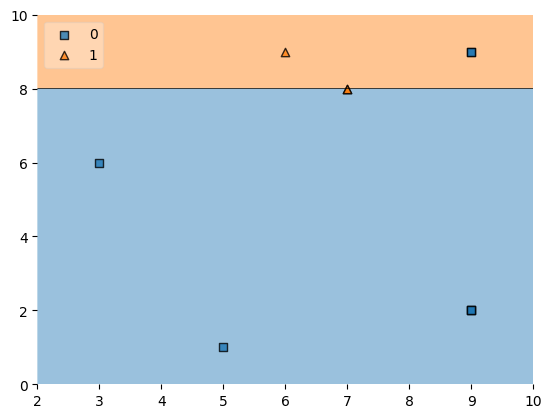

In [196]:
plot_decision_regions(X, y, clf=dt2, legend=2)

In [197]:
second_df['y_pred'] = dt2.predict(X)

In [198]:
second_df

,X1,X2,label,weights,y_pred
4,5,1,0,0.1,0
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0
8,9,9,0,0.1,1
9,9,2,0,0.1,0
9,9,2,0,0.1,0
5,6,9,1,0.1,1
2,3,6,0,0.1,0
7,7,8,1,0.1,1


In [199]:
alpha2 = calculate_model_weight(0.2)

In [200]:
alpha2

np.float64(0.6931471805599453)

In [203]:
# Step 4 - Update weights
def update_row_weights(row,alpha=0.6931471805599453):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [204]:
second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)

In [205]:
second_df

,X1,X2,label,weights,y_pred,updated_weights
4,5,1,0,0.1,0,0.05
7,7,8,1,0.1,1,0.05
8,9,9,0,0.1,1,0.20
9,9,2,0,0.1,0,0.05
8,9,9,0,0.1,1,0.20
9,9,2,0,0.1,0,0.05
9,9,2,0,0.1,0,0.05
5,6,9,1,0.1,1,0.05
2,3,6,0,0.1,0,0.05
7,7,8,1,0.1,1,0.05


In [206]:
second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [207]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
4,5,1,0,0.1,0,0.05,0.0625
7,7,8,1,0.1,1,0.05,0.0625
8,9,9,0,0.1,1,0.20,0.2500
9,9,2,0,0.1,0,0.05,0.0625
8,9,9,0,0.1,1,0.20,0.2500
9,9,2,0,0.1,0,0.05,0.0625
9,9,2,0,0.1,0,0.05,0.0625
5,6,9,1,0.1,1,0.05,0.0625
2,3,6,0,0.1,0,0.05,0.0625
7,7,8,1,0.1,1,0.05,0.0625


In [208]:
second_df['nomalized_weights'].sum()

np.float64(1.0)

In [209]:
second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weights'])

In [210]:
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weights']

In [211]:

second_df[['X1','X2','label','weights','y_pred','nomalized_weights','cumsum_lower','cumsum_upper']]


,X1,X2,label,weights,y_pred,nomalized_weights,cumsum_lower,cumsum_upper
4,5,1,0,0.1,0,0.0625,0.0000,0.0625
7,7,8,1,0.1,1,0.0625,0.0625,0.1250
8,9,9,0,0.1,1,0.2500,0.1250,0.3750
9,9,2,0,0.1,0,0.0625,0.3750,0.4375
8,9,9,0,0.1,1,0.2500,0.4375,0.6875
9,9,2,0,0.1,0,0.0625,0.6875,0.7500
9,9,2,0,0.1,0,0.0625,0.7500,0.8125
5,6,9,1,0.1,1,0.0625,0.8125,0.8750
2,3,6,0,0.1,0,0.0625,0.8750,0.9375
7,7,8,1,0.1,1,0.0625,0.9375,1.0000


In [212]:
index_values = create_new_dataset(second_df)

In [213]:
third_df = second_df.iloc[index_values,[0,1,2,3]]

In [214]:
third_df

,X1,X2,label,weights
2,3,6,0,0.1
5,6,9,1,0.1
5,6,9,1,0.1
8,9,9,0,0.1
2,3,6,0,0.1
8,9,9,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
7,7,8,1,0.1
2,3,6,0,0.1


In [215]:
dt3 = DecisionTreeClassifier(max_depth=1)

In [216]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [217]:
dt3.fit(X,y)

DecisionTreeClassifier(max_depth=1)

<Axes: >

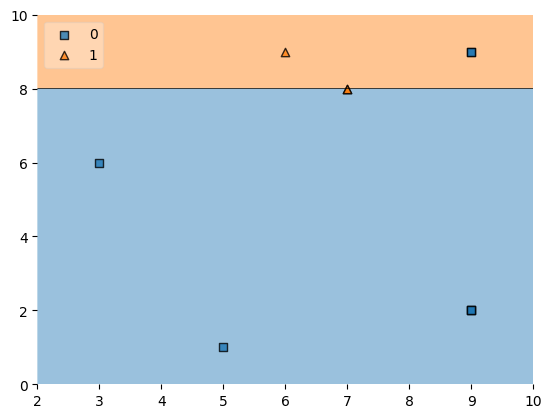

In [218]:
plot_decision_regions(X, y, clf=dt3, legend=2)

In [219]:
third_df['y_pred'] = dt3.predict(X)

In [220]:
third_df

,X1,X2,label,weights,y_pred
2,3,6,0,0.1,0
5,6,9,1,0.1,1
5,6,9,1,0.1,1
8,9,9,0,0.1,0
2,3,6,0,0.1,1
8,9,9,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,1
7,7,8,1,0.1,0
2,3,6,0,0.1,1


In [221]:
alpha3 = calculate_model_weight(0.5)
alpha3


np.float64(0.0)

In [222]:
print(alpha1,alpha2,alpha3)

0.42364893019360184 0.6931471805599453 0.0


In [223]:
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1])

In [224]:
dt2.predict(query)

array([0])

In [225]:
dt3.predict(query)

array([0])

In [226]:
alpha1*1 + alpha2*(-1) + alpha3*(-1)

np.float64(-0.26949825036634345)

In [228]:
np.sign(-0.26949825036634345)

np.float64(-1.0)